In [ ]:
import numpy as np
import random
from time import time
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial as fact

from itertools import combinations_with_replacement
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
wolfSession = WolframLanguageSession(kernel="/Applications/Wolfram.app/Contents/MacOS/WolframKernel")

wolfSession.evaluate(wl.SetDirectory('~/Dropbox/ReLearning the SM/Mathematica'))
wolfSession.evaluate(wl.Get('GroupMath.m'))
# wolfSession.evaluate(wl.Get('spinSinglets.m'))
wolfSession.evaluate(wlexpr('''
Module[{rules},
    rules = Get["spinSinglets.m"];
    DownValues[GetSpins] = rules;
]
'''))

In [12]:
def to_mathematica(obj):
    """Convert Python lists/tuples/arrays to Mathematica list syntax"""
    if isinstance(obj, (list, tuple, np.ndarray)):
        return '{' + ', '.join(map(to_mathematica, obj)) + '}'
    return str(obj)

# Function to find the minimum number of copies of a representation needed to form a singlet, which is useful for determining the number of fields in the baryon operator
def min_copies_for_singlet(gauge_group, fundamental_rep, cutoff = 100):
    """
    Find minimum number of copies of fundamental_rep needed to form a singlet.
    e.g. SU(3) -> 3, E6 -> 3, SO(N) -> 2
    """
    
    # cutoff stops the loop after a certain number of copies, to prevent infinite loops in cases where there is no singlet
    for n in range(1, cutoff + 1):
        rep_str = ", ".join(to_mathematica(fundamental_rep) for _ in range(n))
        _, y = wolfSession.evaluate(wlexpr(f'PermutationSymmetryOfInvariants['+gauge_group+', {'+rep_str+'}]'))         
        if len(y) > 0: 
            return n
        n += 1
    
    raise ValueError(
        f"No singlet found within {cutoff} copies of "
        f"{fundamental_rep} in {gauge_group}"
    )

def RG_coeff(group, reps, spins):
    """ Gets coefficient in RG equation for a given group, set of reps and their spins"""
    coeff = 11/3*wolfSession.evaluate(  wlexpr(f'DynkinIndex['+group+', Adjoint['+group+']]'))
    for i in range(len(reps)):
        if spins[i] ==0: coeff -= wolfSession.evaluate(wlexpr(f'DynkinIndex['+group+', '+to_mathematica(reps[i])+']'))/3
        elif spins[i] ==1: coeff -= 4*wolfSession.evaluate(wlexpr(f'DynkinIndex['+group+', '+to_mathematica(reps[i])+']'))/3
    return coeff

def get_spectrum(group, reps, spins, U1_charges, flavour_charges, d_max = 4):
    """ Takes arguments group (string), 
    reps (tuple of shape (n, ) where n is the number of fields and each element is the dynkin labels of the rep of the corresponding field), 
    spins (numpy array of shape (n, ) where each element is the spin of the corresponding field), 
    U1_charges (numpy array of shape (n, m) where m is the number of U(1) symmetries, 
    flavour_charges (numpy array of shape (n, ) where each element is the flavour charge of the corresponding field),
    d_max (int, maximum number of fields in the operators we consider). 
    Outputs a numpy array of shape (k, m) where k is the number of invariant operators consistent with the spin statistics"""

    spectrum = []
    for d in range(1, d_max + 1):   # d_max is the maximum number of fields in the operators we consider - we could modify this to make it the mass dimension?
        for combo in combinations_with_replacement(range(len(reps)), d):
            idx = list(combo)
            combo_reps    = [reps[i] for i in idx]
            combo_spins   = spins[idx]
            combo_charges = U1_charges[idx]
            combo_flavours = flavour_charges[idx]
            
            rep_str = ", ".join(to_mathematica(r) for r in combo_reps)   # This converts the list of reps to a string in the format that Wolfram expects, allows us to use dynkinlabels instead of dims if we want
            spin_str = ", ".join(to_mathematica(r) for r in combo_spins)   # This converts the list of spins to a string in the format that Wolfram expects
            flavour_str = ", ".join(to_mathematica(r) for r in combo_flavours)   # This converts the list of flavour charges to a string in the format that Wolfram expects
            
            invariants = wolfSession.evaluate(wlexpr(f'GetSpins['+group+', {'+rep_str+'}, {'+spin_str+'}, {'+flavour_str+'}]'))         
            if len(invariants) > 0:
                operator_charge = combo_charges.sum(axis=0)     # U(1) charges
                [spectrum.append(np.append(operator_charge, spin_rep)) for spin_rep, mult in invariants for _ in range(mult)]
    
    # Normalise charges by the gcd of the nonzero charges, done separately for U(1)_em and U(1)_B
    spectrum = np.array(spectrum)
    U1_charges = np.unique(spectrum[:, 0]).astype(int)
    B_charges = np.unique(spectrum[:, 1]).astype(int)
    non_zero_U1 = U1_charges[U1_charges != 0]
    non_zero_B = B_charges[B_charges != 0]
    if len(non_zero_U1) > 0:
        spectrum[:, 0] //= np.gcd.reduce(non_zero_U1)
    if len(non_zero_B) > 0:
        spectrum[:, 1] //= np.gcd.reduce(non_zero_B)

    return spectrum

In [13]:
# Enumerates groups up to some cutoff in N for SU(N), SO(N), and SP(N)
groups = []
for x in range(20):
    groups.append(f'SU{x+2}')
    if x not in [0, 2]:
        groups.append(f'SO{x+2}')
    if x %2 == 0:
        groups.append(f'SP{x+2}')
# Add exceptional groups
[groups.append(x) for x in ['E6', 'E7', 'E8', 'G2', 'F4']]
# Put a cutoff on the dimension of the reps we consider
max_dim = 100

# Create dicitionary of allowed reps for each group, and the minimal U(1) charge we will consider
allowed_reps = {}
minimal_charges = {}
for group in groups:
    reps = wolfSession.evaluate(wlexpr(f'RepsUpToDimN['+group+', '+str(max_dim)+']'))
    allowed_reps[group] = reps
    if len(reps) < 2:   # If there are no reps or just the trivial rep, skip this group
        minimal_charges[group] = 1  # if only rep is trivial, choose integer charges
        continue
    fundamental_rep = reps[1]   # This is the fundamental rep, which is the second element in the list of reps since the first element is the trivial rep
    N = min_copies_for_singlet(group, fundamental_rep, 100)   # This is the minimum number of copies of the fundamental rep needed to form a singlet, which is the number of fields in the baryon operator
    minimal_charges[group] = 1/N  # Quantise the U(1) charges in units of 1/N, so baryons have integer charges (arbitrary choice, may want to update)


In [14]:
# First Generation Quark Model
group = 'SU3' 
reps = [(1, 0), (1, 0), (0, 1), (0, 1)]   # Fundamental x2, antifundamental x2
spins = np.array([2, 2, 2, 2])   # All spin - 1/2
flavours = np.array([1, 2, 3, 4])   # Assign flavour charge +1 to the fundamental and -1 to the antifundamental, this distinguishes the u and d quarks and allows us to get the correct spectrum of hadrons
# Charges under EM, B, S, I_3
# U1_charges = np.array([[2/3, 1/3, 0, 1/2], # u_L 
#                        [-1/3, 1/3, 0, -1/2], # d_L 
#                        [-2/3, -1/3, 0, -1/2], # u^c 
#                        [1/3, -1/3, 0, 1/2]]) # d^c   
U1_charges = np.array([[2, 1, 0, 1/2], # u_L 
                       [-1, 1, 0, -1/2], # d_L 
                       [-2, -1, 0, -1/2], # u^c 
                       [1, -1, 0, 1/2]]) # d^c   

# Charges of invariants under EM, B, S, I_3
# Gives the three pions and the eta, the proton, neutron, and the delta baryons
spectrum = get_spectrum(group, reps, spins, U1_charges, flavours, d_max = 3)

# Mesons first then baryons, then antibaryons, each grouped by spin. 
# We get the spin 0 and spin 1 mesons (pi_0, pi_+, pi_-, eta, rho_0, rho_+, rho_-), then the spin 1/2 baryons (p, n), then the spin 3/2 baryons (delta_++, delta_+, delta_0, delta_-)
sorted(spectrum, key = lambda x: (abs(x[1]), -x[1], x[-1]))

[array([0., 0., 0., 0., 1.]),
 array([1., 0., 0., 1., 1.]),
 array([-1.,  0.,  0., -1.,  1.]),
 array([0., 0., 0., 0., 1.]),
 array([0., 0., 0., 0., 3.]),
 array([1., 0., 0., 1., 3.]),
 array([-1.,  0.,  0., -1.,  3.]),
 array([0., 0., 0., 0., 3.]),
 array([1. , 1. , 0. , 0.5, 2. ]),
 array([ 0. ,  1. ,  0. , -0.5,  2. ]),
 array([2. , 1. , 0. , 1.5, 4. ]),
 array([1. , 1. , 0. , 0.5, 4. ]),
 array([ 0. ,  1. ,  0. , -0.5,  4. ]),
 array([-1. ,  1. ,  0. , -1.5,  4. ]),
 array([-1. , -1. ,  0. , -0.5,  2. ]),
 array([ 0. , -1. ,  0. ,  0.5,  2. ]),
 array([-2. , -1. ,  0. , -1.5,  4. ]),
 array([-1. , -1. ,  0. , -0.5,  4. ]),
 array([ 0. , -1. ,  0. ,  0.5,  4. ]),
 array([ 1. , -1. ,  0. ,  1.5,  4. ])]

In [15]:
time_per_ite = []
for n in range(6, 22, 4):   # Try different numbers of fields
    start_time = time.time()
    print(n)
    j = 0
    while j< 100:
        # Pick a random model from the allowed reps, keep the group = SU(3) for simplicity
        group = 'SU3'
        n_reps = n
        reps = random.sample(allowed_reps[group], n_reps) # Pick some reps
        spins = np.asarray(random.choices([1, 2], k = n_reps))   # Random spins - either fermions or scalars
        flavours = np.array([i + 1 for i in range(n_reps)])   # Assign a different flavour to each field
        # q_min = minimal_charges[group]
        # Charges under EM, B,  S, I_3
        U1_charges = np.array([random.choices([i for i in range(-3, 3)], k = 4) for _ in range(n_reps)])
        # Put isospins into half integer values
        U1_charges[:, -1] = U1_charges[:, -1] / 2 
        # Gives the three pions and the eta, the proton, neutron, and the delta baryons
        get_spectrum(group, reps, spins, U1_charges, flavours, d_max = 3)
        j += 1
    end_time = time.time()
    # print(f"Time taken: {(end_time - start_time)/100} seconds")
    time_per_ite.append((end_time - start_time)/100)

6
10
14
18


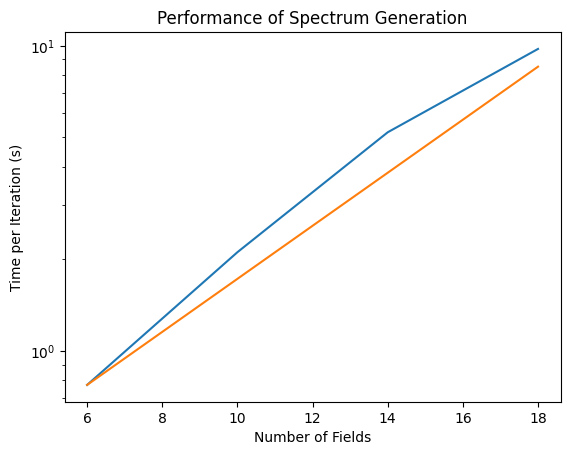

In [27]:
n_rep_vals = list(range(6, 22, 4))
plt.plot(n_rep_vals, time_per_ite)
plt.plot(n_rep_vals, time_per_ite[0]*np.exp((np.array(n_rep_vals)-n_rep_vals[0])/5))   # Exponential growth with number of fields
# plt.plot(n_rep_vals, time_per_ite[0]*fact(np.array(n_rep_vals))/fact(n_rep_vals[0]))   # Factorial growth with number of fields
plt.xlabel('Number of Fields')
plt.ylabel('Time per Iteration (s)')
plt.yscale('log')
plt.title('Performance of Spectrum Generation')
plt.show()